In [ ]:
!pip install -q gdown
import os
import shutil
import zipfile
import gdown


file_id="1CTMB7i4VUkQQCYWeVEiEzKAEXaq7MQYt"
url=f"https://drive.google.com/uc?id={file_id}"


local_zip_path="/content/FD3611.zip"
extract_path="/content/FD3611"
clean_dataset_path="/content/FD3611_clean"


if os.path.exists(local_zip_path):
    os.remove(local_zip_path)
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
if os.path.exists(clean_dataset_path):
    shutil.rmtree(clean_dataset_path)


gdown.download(url, local_zip_path, quiet=False)

print("ZIP downloaded to Colab local storage!")

Downloading...
From (original): https://drive.google.com/uc?id=1CTMB7i4VUkQQCYWeVEiEzKAEXaq7MQYt
From (redirected): https://drive.google.com/uc?id=1CTMB7i4VUkQQCYWeVEiEzKAEXaq7MQYt&confirm=t&uuid=1bde2581-7a18-4d9b-95e6-21bd89f84c17
To: /content/FD3611.zip
100%|██████████| 4.71G/4.71G [01:06<00:00, 70.5MB/s]

ZIP downloaded to Colab local storage!


In [ ]:
with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")
print("Extracted folders:")
print(os.listdir(extract_path))


os.makedirs(clean_dataset_path, exist_ok=True)
valid_classes=[
    "Diabetic_Retinopathy",
    "Media_Hazy",
    "Myopic_Retinopathy",
    "Normal",
    "Optic_Disc_Disorder"
]


for cls in valid_classes:
    src = os.path.join(extract_path, 'FD3611', cls)
    dst = os.path.join(clean_dataset_path, cls)

    shutil.copytree(src, dst)
print("Clean dataset created successfully!")
print(os.listdir(clean_dataset_path))


dataset_path=clean_dataset_path
print("Final dataset path:")
print(dataset_path)


ZIP extracted successfully!
Extracted folders:
['Supporting_Documents', 'FD3611']
Clean dataset created successfully!
['Media_Hazy', 'Normal', 'Diabetic_Retinopathy', 'Myopic_Retinopathy', 'Optic_Disc_Disorder']
Final dataset path:
/content/FD3611_clean


In [ ]:

!pip install -q opencv-python scikit-learn tqdm

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

IMG_SIZE=224
BATCH_SIZE=16
EPOCHS_STAGE1=8
EPOCHS_STAGE2=10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:

class CLAHETransform:
    def __call__(self, img):
        img=np.array(img)

        lab=cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe=cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        cl=clahe.apply(l)
        merged = cv2.merge((cl, a, b))
        enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

        return enhanced

In [ ]:

train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    CLAHETransform(),
    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.15
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    CLAHETransform(),
    transforms.ToPILImage(),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset=datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

class_names=full_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)
print("Total images:", len(full_dataset))

Classes: ['Diabetic_Retinopathy', 'Media_Hazy', 'Myopic_Retinopathy', 'Normal', 'Optic_Disc_Disorder']
Number of classes: 5
Total images: 3611


Class distribution:
Diabetic_Retinopathy: 349
Media_Hazy: 464
Myopic_Retinopathy: 291
Normal: 2220
Optic_Disc_Disorder: 287


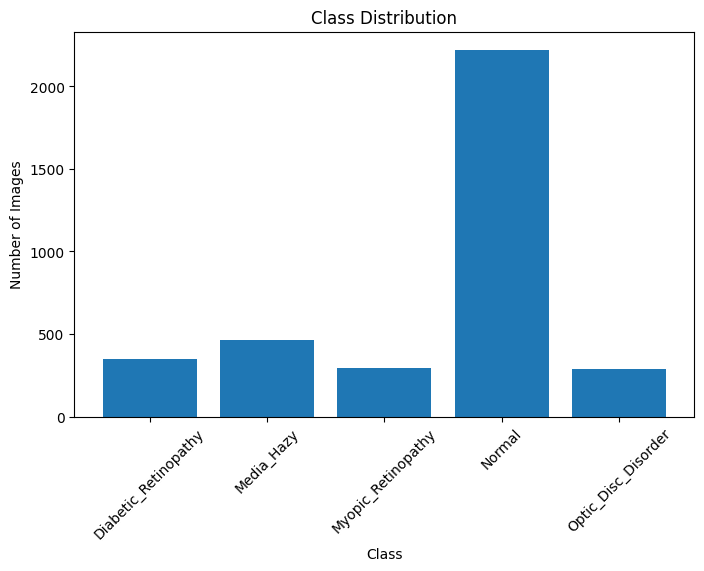

In [ ]:

targets=full_dataset.targets
class_counts=Counter(targets)

print("Class distribution:")
for class_idx, count in sorted(class_counts.items()):
    print(f"{class_names[class_idx]}: {count}")

plt.figure(figsize=(8,5))
plt.bar(
    [class_names[i] for i in sorted(class_counts.keys())],
    [class_counts[i] for i in sorted(class_counts.keys())]
)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:

train_size=int(0.7 * len(full_dataset))
val_size=int(0.15 * len(full_dataset))
test_size=len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset=random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
val_dataset.dataset.transform=test_transform
test_dataset.dataset.transform=test_transform

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2527
Validation: 541
Test: 543


In [ ]:

train_labels=[full_dataset.targets[i] for i in train_dataset.indices]
train_class_counts=Counter(train_labels)
print("Train class distribution:")
for class_idx, count in sorted(train_class_counts.items()):
    print(f"{class_names[class_idx]}: {count}")

class_weights_sampler={
    cls: 1.0 / count
    for cls, count in train_class_counts.items()
}

sample_weights=[
    class_weights_sampler[label]
    for label in train_labels
]

sampler=WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("WeightedRandomSampler applied.")

Train class distribution:
Diabetic_Retinopathy: 240
Media_Hazy: 317
Myopic_Retinopathy: 211
Normal: 1560
Optic_Disc_Disorder: 199
WeightedRandomSampler applied.


In [ ]:

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden=max(channels // reduction, 1)

        self.avg_pool=nn.AdaptiveAvgPool2d(1)
        self.max_pool=nn.AdaptiveMaxPool2d(1)

        self.mlp=nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out=self.mlp(self.avg_pool(x))
        max_out=self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding=kernel_size // 2

        self.conv=nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channel_attention=ChannelAttention(channels)
        self.spatial_attention=SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

In [ ]:

class DualBackboneCBAMViT(nn.Module):
    def __init__(self, num_classes, embed_dim=256, num_heads=4, num_layers=2):
        super().__init__()

        
        eff=models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        self.efficientnet=eff.features

        self.eff_proj=nn.Sequential(
            nn.Conv2d(1280, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )


        resnet=models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )
        self.resnet=nn.Sequential(*list(resnet.children())[:-2])

        self.res_proj=nn.Sequential(
            nn.Conv2d(2048, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        
        self.fusion_proj=nn.Sequential(
            nn.Conv2d(embed_dim * 2, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        self.cbam=CBAM(embed_dim)

        
        encoder_layer=nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.3,
            batch_first=True
        )

        self.transformer=nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )


        self.attention_pool=nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        #
        self.classifier=nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        eff_feat=self.efficientnet(x)          
        eff_feat=self.eff_proj(eff_feat)        

        res_feat=self.resnet(x)                 
        res_feat=self.res_proj(res_feat)        #

        fused=torch.cat([eff_feat, res_feat], dim=1)  

        fused=self.fusion_proj(fused)          
        fused=self.cbam(fused)

        B, C, H, W=fused.shape
        tokens=fused.flatten(2).transpose(1, 2)

        transformer_out=self.transformer(tokens)

        attn_scores=self.attention_pool(transformer_out)
        attn_weights=torch.softmax(attn_scores, dim=1)

        pooled=torch.sum(attn_weights * transformer_out, dim=1)

        output=self.classifier(pooled)

        return output

In [ ]:

model=DualBackboneCBAMViT(NUM_CLASSES).to(DEVICE)
for param in model.efficientnet.parameters():
    param.requires_grad = False
for param in model.resnet.parameters():
    param.requires_grad = False

print("Pretrained backbones frozen for Stage 1.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Pretrained backbones frozen for Stage 1.


In [ ]:

loss_weights=[]
total_train=len(train_labels)

for i in range(NUM_CLASSES):
    count=train_class_counts[i]
    weight=total_train / (NUM_CLASSES * count)
    loss_weights.append(weight)

loss_weights=torch.tensor(loss_weights, dtype=torch.float).to(DEVICE)

criterion=nn.CrossEntropyLoss(
    weight=loss_weights,
    label_smoothing=0.05
)

optimizer=optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

print("Loss weights:", loss_weights)

Loss weights: tensor([2.1058, 1.5943, 2.3953, 0.3240, 2.5397], device='cuda:0')


In [ ]:

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience=5, save_name="best_model.pth"):
    best_val_acc=0.0
    best_val_loss=float("inf")
    patience_counter=0

    history={
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()

        train_loss=0.0
        train_correct=0
        train_total=0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)

            optimizer.zero_grad()

            outputs=model(images)
            loss=criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds=torch.max(outputs, 1)
            train_correct+=(preds == labels).sum().item()
            train_total+=labels.size(0)

        train_loss=train_loss / len(train_loader)
        train_acc=train_correct / train_total

        model.eval()

        val_loss=0.0
        val_correct=0
        val_total=0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs=model(images)
                loss=criterion(outputs, labels)

                val_loss += loss.item()

                _, preds=torch.max(outputs, 1)
                val_correct+=(preds == labels).sum().item()
                val_total+=labels.size(0)

        val_loss=val_loss / len(val_loader)
        val_acc=val_correct / val_total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print("-" * 60)
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_name)
            print("Best model saved.")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Early stopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    return history

In [ ]:

history_stage1=train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=EPOCHS_STAGE1,
    patience=4,
    save_name="best_dual_backbone_cbam_vit.pth"
)

Epoch 1/8 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.07s/it]


------------------------------------------------------------
Epoch [1/8]
Train Loss: 0.3046 | Train Acc: 0.9189
Val Loss: 1.0436 | Val Acc: 0.7542
Best model saved.


Epoch 2/8 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.09s/it]


------------------------------------------------------------
Epoch [2/8]
Train Loss: 0.2874 | Train Acc: 0.9426
Val Loss: 1.0268 | Val Acc: 0.8226
Best model saved.


Epoch 3/8 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.08s/it]


...

------------------------------------------------------------
Epoch [6/8]
Train Loss: 0.2658 | Train Acc: 0.9620
Val Loss: 1.1278 | Val Acc: 0.7394
Early stopping counter: 1/4


Epoch 7/8 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.08s/it]


------------------------------------------------------------
Epoch [7/8]
Train Loss: 0.2548 | Train Acc: 0.9664
Val Loss: 1.0655 | Val Acc: 0.8318
Best model saved.
Early stopping counter: 2/4


Epoch 8/8 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.09s/it]

------------------------------------------------------------
Epoch [8/8]
Train Loss: 0.2749 | Train Acc: 0.9541
Val Loss: 1.0640 | Val Acc: 0.8022
Early stopping counter: 3/4


In [ ]:

model.load_state_dict(torch.load("best_dual_backbone_cbam_vit.pth", map_location=DEVICE))


for param in model.efficientnet[5:].parameters():
    param.requires_grad = True
for param in model.resnet[-1].parameters():
    param.requires_grad = True

print("Deeper pretrained blocks unfrozen for Stage 2.")

optimizer=optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6,
    weight_decay=1e-4
)

scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

history_stage2=train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=5,
    patience=5,
    save_name="best_dual_backbone_cbam_vit.pth"
)

Deeper pretrained blocks unfrozen for Stage 2.


Epoch 1/5 Validation: 100%|██████████| 34/34 [00:36<00:00,  1.08s/it]


------------------------------------------------------------
Epoch [1/5]
Train Loss: 0.2565 | Train Acc: 0.9683
Val Loss: 1.0499 | Val Acc: 0.8262
Best model saved.


Epoch 2/5 Validation: 100%|██████████| 34/34 [00:37<00:00,  1.09s/it]


------------------------------------------------------------
Epoch [2/5]
Train Loss: 0.2495 | Train Acc: 0.9763
Val Loss: 1.0469 | Val Acc: 0.8262


...

------------------------------------------------------------
Epoch [3/5]
Train Loss: 0.2449 | Train Acc: 0.9755
Val Loss: 1.0627 | Val Acc: 0.8484
Best model saved.
Early stopping counter: 1/5


Epoch 4/5 Validation: 100%|██████████| 34/34 [00:37<00:00,  1.09s/it]


------------------------------------------------------------
Epoch [4/5]
Train Loss: 0.2502 | Train Acc: 0.9782
Val Loss: 1.0217 | Val Acc: 0.8373


Epoch 5/5 Validation: 100%|██████████| 34/34 [00:37<00:00,  1.09s/it]

------------------------------------------------------------
Epoch [5/5]
Train Loss: 0.2423 | Train Acc: 0.9802
Val Loss: 1.0178 | Val Acc: 0.8170


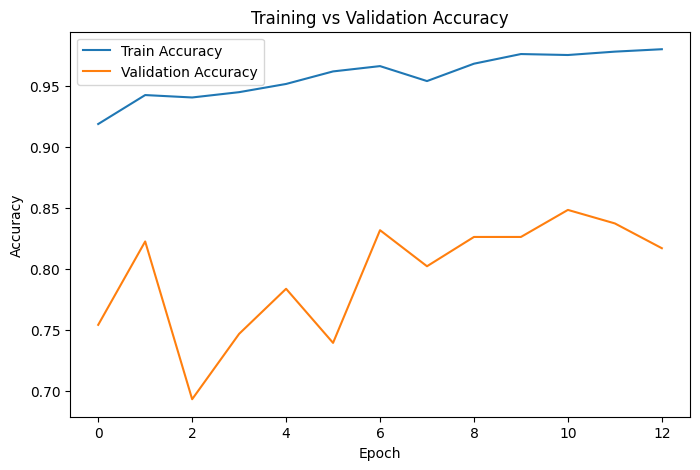

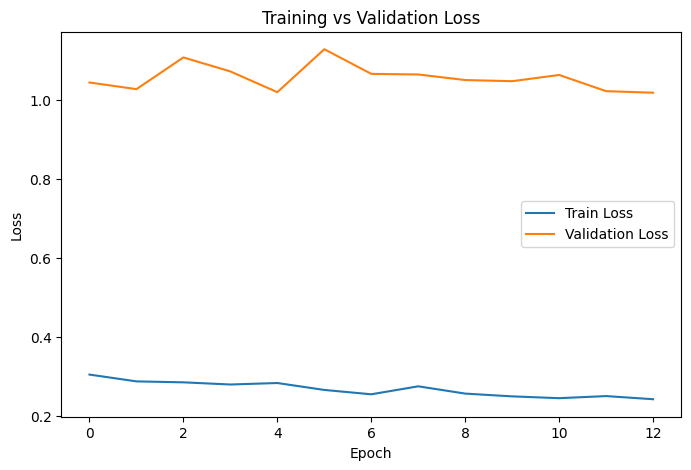

In [ ]:

train_acc = history_stage1["train_acc"] + history_stage2["train_acc"]
val_acc = history_stage1["val_acc"] + history_stage2["val_acc"]
train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss = history_stage1["val_loss"] + history_stage2["val_loss"]

plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:

model.load_state_dict(torch.load("best_dual_backbone_cbam_vit.pth", map_location=DEVICE))
model.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images=images.to(DEVICE)
        labels=labels.to(DEVICE)

        outputs=model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Testing: 100%|██████████| 34/34 [00:37<00:00,  1.11s/it]

Classification Report:
                      precision    recall  f1-score   support

Diabetic_Retinopathy       0.75      0.74      0.75        62
          Media_Hazy       0.69      0.83      0.75        72
  Myopic_Retinopathy       0.54      0.73      0.62        37
              Normal       0.95      0.85      0.90       331
 Optic_Disc_Disorder       0.46      0.54      0.49        41

            accuracy                           0.81       543
           macro avg       0.68      0.74      0.70       543
        weighted avg       0.83      0.81      0.81       543

Confusion Matrix:
[[ 46   9   2   3   2]
 [  7  60   3   1   1]
 [  2   1  27   4   3]
 [  6  10  12 283  20]
 [  0   7   6   6  22]]


In [ ]:
# === Cell 17: Save deployment artifacts to Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import inspect


deploy_dir = "/content/drive/MyDrive/FD3611_deployment"
os.makedirs(deploy_dir, exist_ok=True)


shutil.copy(
    "best_dual_backbone_cbam_vit.pth",
    os.path.join(deploy_dir, "best_dual_backbone_cbam_vit.pth")
)

# 2. save class names (needed to map prediction index -> label)
with open(os.path.join(deploy_dir, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

\
config = {
    "img_size": IMG_SIZE,
    "embed_dim": 256,
    "num_heads": 4,
    "num_layers": 2,
    "num_classes": NUM_CLASSES,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
    "backbones": ["efficientnet_b0", "resnet50"],
    "uses_clahe": True
}

with open(os.path.join(deploy_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)


torch.save(model, os.path.join(deploy_dir, "full_model.pth"))


clahe_transform_source = """
class CLAHETransform:
    def __call__(self, img):
        img = np.array(img)

        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        cl = clahe.apply(l)
        merged = cv2.merge((cl, a, b))
        enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

        return enhanced
"""

channel_attention_source = """
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)
"""

spatial_attention_source = """
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))
"""

cbam_source = """
class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channel_attention = ChannelAttention(channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x
"""

dual_backbone_cbam_vit_source = """
class DualBackboneCBAMViT(nn.Module):
    def __init__(self, num_classes, embed_dim=256, num_heads=4, num_layers=2):
        super().__init__()

        # EfficientNet-B0
        eff = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        self.efficientnet = eff.features

        self.eff_proj = nn.Sequential(
            nn.Conv2d(1280, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        # ResNet50
        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])

        self.res_proj = nn.Sequential(
            nn.Conv2d(2048, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        # Fusion + CBAM
        self.fusion_proj = nn.Sequential(
            nn.Conv2d(embed_dim * 2, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        self.cbam = CBAM(embed_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=0.3,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Attention Pooling
        self.attention_pool = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        eff_feat = self.efficientnet(x)          # (B, 1280, 7, 7)
        eff_feat = self.eff_proj(eff_feat)        # (B, embed_dim, 7, 7)

        res_feat = self.resnet(x)                 # (B, 2048, 7, 7)
        res_feat = self.res_proj(res_feat)        # (B, embed_dim, 7, 7)

        fused = torch.cat([eff_feat, res_feat], dim=1)  # (B, embed_dim*2, 7, 7)

        fused = self.fusion_proj(fused)           # (B, embed_dim, 7, 7)
        fused = self.cbam(fused)

        B, C, H, W = fused.shape
        tokens = fused.flatten(2).transpose(1, 2)  # (B, H*W, embed_dim)

        transformer_out = self.transformer(tokens)

        attn_scores = self.attention_pool(transformer_out)
        attn_weights = torch.softmax(attn_scores, dim=1)

        pooled = torch.sum(attn_weights * transformer_out, dim=1)

        output = self.classifier(pooled)

        return output
"""

code_to_save = (
    clahe_transform_source + "\n\n"
    + channel_attention_source + "\n\n"
    + spatial_attention_source + "\n\n"
    + cbam_source + "\n\n"
    + dual_backbone_cbam_vit_source
)

with open(os.path.join(deploy_dir, "model_def.py"), "w") as f:
    f.write("import torch\nimport torch.nn as nn\nimport cv2\nimport numpy as np\nfrom torchvision import models\n\n\n")
    f.write(code_to_save)

print("Saved to:", deploy_dir)
print("Files:", os.listdir(deploy_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/FD3611_deployment
Files: ['best_dual_backbone_cbam_vit.pth', 'class_names.json', 'config.json', 'full_model.pth', 'model_def.py']


In [ ]:
import os
import json
import cv2
import numpy as np
import torch
from torchvision import transforms


deploy_dir = "/content/drive/MyDrive/FD3611_deployment"


with open(os.path.join(deploy_dir, "config.json")) as f:
    config = json.load(f)

with open(os.path.join(deploy_dir, "class_names.json")) as f:
    class_names = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"


import importlib.util
spec = importlib.util.spec_from_file_location("model_def", os.path.join(deploy_dir, "model_def.py"))
model_def = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_def)

model = model_def.DualBackboneCBAMViT(
    num_classes=config["num_classes"],
    embed_dim=config["embed_dim"],
    num_heads=config["num_heads"],
    num_layers=config["num_layers"]
).to(device)

model.load_state_dict(
    torch.load(os.path.join(deploy_dir, "best_dual_backbone_cbam_vit.pth"), map_location=device)
)
model.eval()


inference_transform = transforms.Compose([
    transforms.ToPILImage(), 
    transforms.Resize((config["img_size"], config["img_size"])),
    model_def.CLAHETransform(),
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=config["imagenet_mean"], std=config["imagenet_std"])
])


def predict(image_path):
    # load image as RGB
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Image not found or could not be loaded from: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tensor = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    predicted_class = class_names[pred_idx.item()]
    confidence = conf.item()

    return predicted_class, confidence, probs.cpu().numpy()[0]



from google.colab import files

uploaded = files.upload()  
image_path = list(uploaded.keys())[0] 

pred_class, conf, all_probs = predict(image_path)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {conf:.4f}")
print("\nAll class probabilities:")
for name, p in zip(class_names, all_probs):
    print(f"  {name}: {p:.4f}")

Saving 13430_left.png to 13430_left (1).png
Predicted class: Diabetic_Retinopathy
Confidence: 0.9879

All class probabilities:
  Diabetic_Retinopathy: 0.9879
  Media_Hazy: 0.0023
  Myopic_Retinopathy: 0.0050
  Normal: 0.0004
  Optic_Disc_Disorder: 0.0044
